# Final Project: [ชื่อโครงงาน]
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** [ระบุชื่อสมาชิกและรหัสนักศึกษา]
- สมาชิกที่ 1: นาย ธนวรรธ ทองตื้อ (68114540258)
- สมาชิกที่ 2: ชื่อ-นามสกุล (รหัส)

**Dataset:** [https://www.kaggle.com/datasets/aramelheni/cafe-sales-dataset-clean]

**Problem Statement:** [อธิบาย 2-3 ประโยคว่าปัญหาคืออะไร ทำไมถึงสนใจ dataset นี้]

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ✅ |
| CLO2 (Statistical Learning) | Part 3 | ⬜ |
| CLO3 (Regression/Classification) | Part 4 | ⬜ |
| CLO4 (Model Selection) | Part 5 | ⬜ |

In [1]:
# ─── Import libraries ──────────────────────────────────────────────
# TODO: เพิ่ม/ลบ libraries ตามที่โครงงานของคุณต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [2]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

# TODO: แทนที่ด้วย path หรือวิธีโหลด dataset ของคุณ
df = pd.read_csv('Cleaned_DataSet.csv')

# แสดงข้อมูลพื้นฐาน
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Missing values:\n{df.isnull().sum()}')
print(f"Types: {df.dtypes}")
df.head()

Shape: (9741, 6)
Columns: ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Transaction Date']
Missing values:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Transaction Date    0
dtype: int64
Types: Transaction ID          str
Item                    str
Quantity            float64
Price Per Unit      float64
Total Spent         float64
Transaction Date        str
dtype: object


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Transaction Date
0,TXN_1961373,coffee,2.0,2.0,4.0,2023-09-08
1,TXN_4977031,cake,4.0,3.0,12.0,2023-05-16
2,TXN_4271903,cookie,4.0,1.0,8.0,2023-07-19
3,TXN_7034554,salad,2.0,5.0,10.0,2023-04-27
4,TXN_3160411,coffee,2.0,2.0,4.0,2023-06-11


          Quantity  Price Per Unit  Total Spent
count  9741.000000     9741.000000  9741.000000
mean      2.977312        2.901499     8.449287
std       1.366510        1.217124     5.307016
min       1.000000        1.000000     1.000000
25%       2.000000        2.000000     4.000000
50%       3.000000        3.000000     8.000000
75%       4.000000        4.000000    12.000000
max       5.000000        5.000000    20.000000


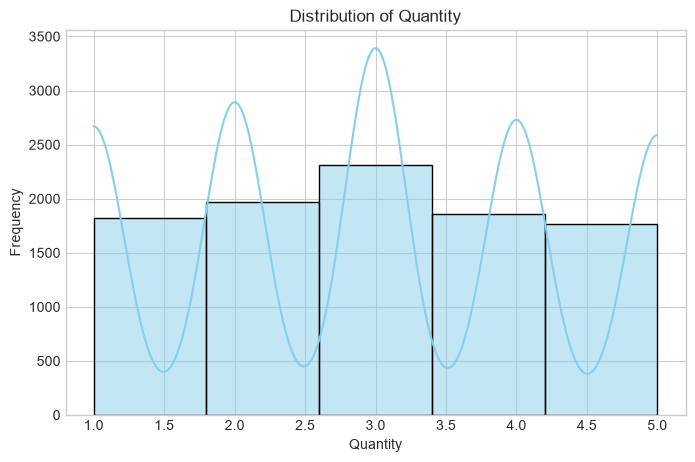

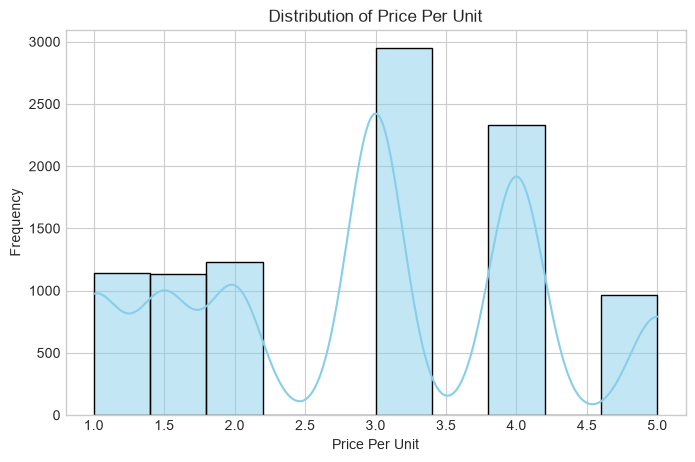

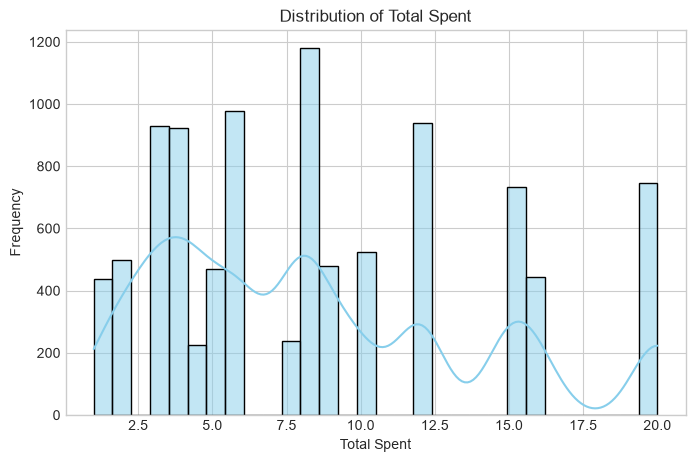

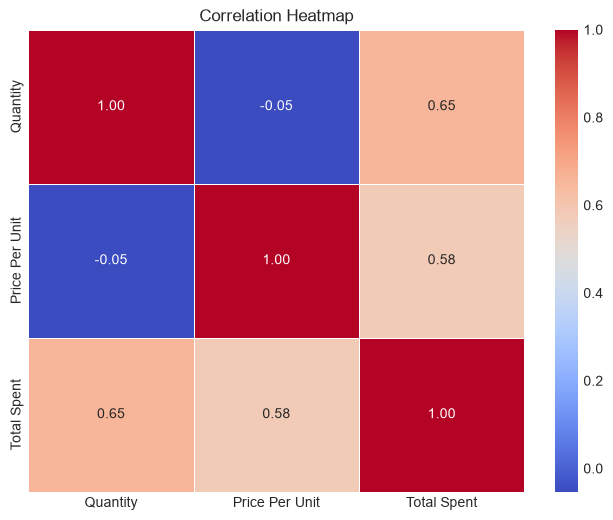

In [3]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

# TODO: เพิ่ม code สำหรับ:
print(df.describe())

target = ['Quantity', 'Price Per Unit', 'Total Spent']
bins = [5,10,30]

for i,j in zip(target,bins):
    plt.figure(figsize=(8, 5))

    dynamic_bins = min(df[i].nunique(), 30)

    sns.histplot(data=df, x=i, kde=True, bins=j, color='skyblue')

    plt.title(f'Distribution of {i}')
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.show()

# 3. Correlation heatmap
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()


---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**เลือก Task:** ✅ **Task C — Covariance/Correlation Analysis (Eigendecomposition ของ Covariance Matrix)**

**คำอธิบาย:**
* เลือก Task C เพราะเป็นการประยุกต์ใช้แนวคิด Eigenvalues และ Eigenvectors จาก Linear Algebra โดยตรงกับข้อมูลจริง ผ่านการหา Eigendecomposition ของ Covariance Matrix ที่วัดความแปรปรวนและความสัมพันธ์เชิงเส้นของตัวแปรได้ในคราวเดียว 
* ตัวแปรเชิงตัวเลขทั้ง 3 ตัว (`Quantity`, `Price Per Unit`, `Total Spent`) มีความสัมพันธ์เชิงตรรกะต่อกันตามสูตร $Total\ Spent = Quantity \times Price\ Per\ Unit$ การวิเคราะห์ Covariance Matrix จึงเหมาะกับการไขโครงสร้างความสัมพันธ์นี้ โดย Eigenvector จะชี้ทิศทางที่ข้อมูลแปรปรวนมากที่สุด (Principal Axis)
* Eigenvalue จะบอกปริมาณความแปรปรวนในทิศทางนั้น

**Insight ที่คาดว่าจะได้:**
- ความสัมพันธ์เชิงเส้นระหว่างปริมาณสินค้า ราคาต่อหน่วย และยอดใช้จ่ายรวม ว่าตัวแปรใดเกี่ยวข้องกันมากที่สุด
- ทิศทางของแกนความแปรปรวนหลัก (Principal Axis) และสัดส่วนความแปรปรวนที่แต่ละแกนอธิบายได้ โดยคาดว่าความแปรปรวนส่วนใหญ่จะกระจุกตัวอยู่ใน 2 ทิศทางแรก เพราะความสัมพันธ์ $Total\ Spent \approx Quantity \times Price$ ทำให้ข้อมูลมีมิติที่แท้จริงน้อยกว่า 3 มิติ
- การแยกประเภทของบิลตามแกนหลัก เช่น บิลแบบ "ซื้อเยอะ-ของราคาถูก" กับ "ซื้อน้อย-ของราคาแพง" ที่คาดว่าจะปรากฏในทิศทางตรงข้ามกันของ eigenvector ที่สอง

=== 1. Covariance Matrix (of standardized data = Correlation Matrix) ===
                Quantity  Price Per Unit  Total Spent
Quantity          1.0000         -0.0529       0.6546
Price Per Unit   -0.0529          1.0000       0.5785
Total Spent       0.6546          0.5785       1.0000

Symmetric check: max|C - C^T| = 0.00e+00

=== 2. Verification: C v = λ v ===
PC1: ||C v - λ v|| = 5.09e-16
PC2: ||C v - λ v|| = 3.59e-16
PC3: ||C v - λ v|| = 6.29e-16

=== 3. Orthogonality check (Gram matrix V^T V) ===
     PC1  PC2  PC3
PC1  1.0  0.0  0.0
PC2  0.0  1.0  0.0
PC3  0.0  0.0  1.0

=== 4. Eigenvalues & Explained Variance ===
     Eigenvalue (λ)  Explained Variance (%)
PC1          1.8478                 61.5923
PC2          1.0525                 35.0828
PC3          0.0997                  3.3249

Sum of eigenvalues (trace of C) = 3.0000 (= จำนวน features, เพราะแต่ละตัวแปรถูก standardize ให้ variance = 1)

=== 5. Eigenvectors (Principal Axis Directions / Loadings) ===
                   

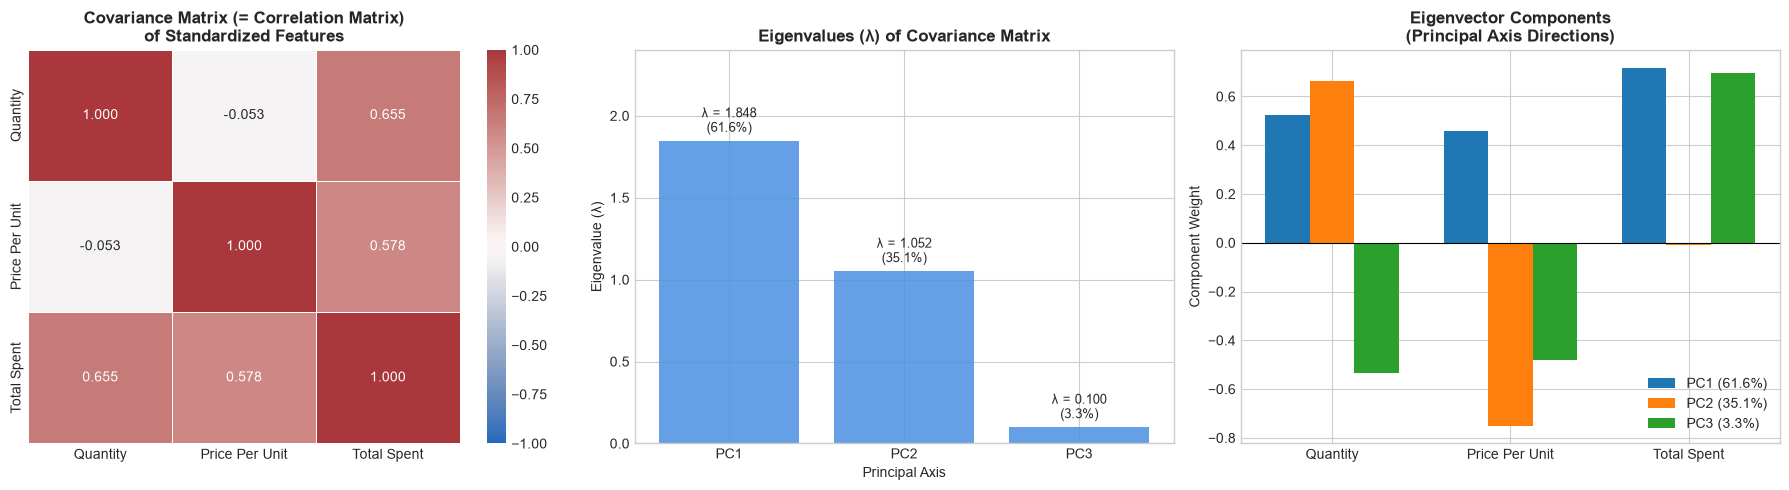

In [4]:
# ─── CLO1: Linear Algebra Analysis (Task C — Covariance/Correlation Analysis) ──
# วัตถุประสงค์: Eigendecomposition ของ Covariance Matrix เพื่อวิเคราะห์
# โครงสร้างความแปรปรวนและความสัมพันธ์เชิงเส้นของตัวแปร

# 1. เลือก Features เชิงตัวเลขที่ใช้วิเคราะห์
feature_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
X = df[feature_cols].values
n_samples, n_features = X.shape

# 2. Standardization (Z-score Normalization)
# เหตุผล: ทำให้ทุกตัวแปรมี mean = 0 และ variance = 1 เท่ากัน
# Covariance Matrix ของข้อมูลที่ standardize แล้วจึงเท่ากับ Correlation Matrix พอดี
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0, ddof=1)
X_scaled = (X - X_mean) / X_std

# 3. คำนวณ Covariance Matrix ตามสูตร Linear Algebra: C = (1/(N-1)) * X_scaled^T @ X_scaled
C = (1 / (n_samples - 1)) * (X_scaled.T @ X_scaled)

print("=== 1. Covariance Matrix (of standardized data = Correlation Matrix) ===")
cov_df = pd.DataFrame(C, index=feature_cols, columns=feature_cols)
print(cov_df.round(4))
print(f"\nSymmetric check: max|C - C^T| = {np.max(np.abs(C - C.T)):.2e}")

# 4. Eigendecomposition ด้วย np.linalg.eigh
# (eigh ออกแบบมาสำหรับ Symmetric/Hermitian Matrix โดยเฉพาะ)
eigenvalues, eigenvectors = np.linalg.eigh(C)

# เรียงลำดับจากค่า Eigenvalue มากไปหาน้อย (Descending order)
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# 5. ตรวจสอบนิยามของ Eigenpair: C v = λ v
print("\n=== 2. Verification: C v = λ v ===")
for i in range(n_features):
    v = eigenvectors[:, i]
    residual = np.linalg.norm(C @ v - eigenvalues[i] * v)
    print(f"PC{i+1}: ||C v - λ v|| = {residual:.2e}")

# ตรวจสอบความตั้งฉากของ Eigenvectors: v_i · v_j = 0 (i ≠ j) และ |v| = 1
print("\n=== 3. Orthogonality check (Gram matrix V^T V) ===")
gram = eigenvectors.T @ eigenvectors
gram_df = pd.DataFrame(gram,
                       index=[f"PC{i+1}" for i in range(n_features)],
                       columns=[f"PC{i+1}" for i in range(n_features)])
print(gram_df.round(4))

# 6. สรุป Eigenvalues และ Explained Variance
# โดย Eigenvalue แต่ละตัว = ความแปรปรวนของข้อมูลในทิศทางของ Eigenvector นั้น
explained_variance_ratio = (eigenvalues / np.sum(eigenvalues)) * 100

print("\n=== 4. Eigenvalues & Explained Variance ===")
summary_df = pd.DataFrame({
    'Eigenvalue (λ)': eigenvalues,
    'Explained Variance (%)': explained_variance_ratio
}, index=[f"PC{i+1}" for i in range(n_features)])
print(summary_df.round(4))
print(f"\nSum of eigenvalues (trace of C) = {np.sum(eigenvalues):.4f} (= จำนวน features, เพราะแต่ละตัวแปรถูก standardize ให้ variance = 1)")

print("\n=== 5. Eigenvectors (Principal Axis Directions / Loadings) ===")
loadings_df = pd.DataFrame(eigenvectors, index=feature_cols,
                           columns=[f"PC{i+1}" for i in range(n_features)])
print(loadings_df.round(4))

# 7. Visualization: แสดง 3 กราฟวิเคราะห์
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# กราฟ 1: Heatmap ของ Covariance (Correlation) Matrix
sns.heatmap(cov_df, annot=True, cmap='vlag', center=0, vmin=-1, vmax=1,
            fmt='.3f', linewidths=0.5, ax=axes[0])
axes[0].set_title('Covariance Matrix (= Correlation Matrix)\nof Standardized Features', fontsize=12, fontweight='bold')

# กราฟ 2: Eigenvalues ของ Covariance Matrix พร้อมสัดส่วน Explained Variance
bars = axes[1].bar([f"PC{i+1}" for i in range(n_features)], eigenvalues,
                   color='#4A90E2', alpha=0.85)
axes[1].set_title('Eigenvalues (λ) of Covariance Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Eigenvalue (λ)')
axes[1].set_xlabel('Principal Axis')
for i, bar in enumerate(bars):
    axes[1].text(bar.get_x() + bar.get_width()/2.0, bar.get_height() + 0.03,
                 f'λ = {eigenvalues[i]:.3f}\n({explained_variance_ratio[i]:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_ylim(0, eigenvalues.max() * 1.3)

# กราฟ 3: องค์ประกอบของ Eigenvector แต่ละตัว (ทิศทางของ Principal Axis ใน feature space)
x_pos = np.arange(n_features)
width = 0.25
for i in range(n_features):
    axes[2].bar(x_pos + (i - 1) * width, eigenvectors[:, i], width,
                label=f'PC{i+1} ({explained_variance_ratio[i]:.1f}%)')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(feature_cols)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Eigenvector Components\n(Principal Axis Directions)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Component Weight')
axes[2].legend()

plt.tight_layout()
plt.show()

**Insight จาก CLO1 Analysis (Task C):**
1. **โครงสร้าง Covariance/Correlation Matrix:**
   - `Total Spent` มีความสัมพันธ์เชิงเส้นเชิงบวกกับทั้ง `Quantity` (r = 0.6546) และ `Price Per Unit` (r = 0.5785) สอดคล้องกับความสัมพันธ์เชิงตรรกะว่า $Total\ Spent = Quantity \times Price\ Per\ Unit$
   - ในทางกลับกัน `Quantity` กับ `Price Per Unit` แทบไม่มีความสัมพันธ์เชิงเส้นต่อกัน (r = -0.0529) แสดงว่าจำนวนสินค้าที่ซื้อเป็นอิสระจากราคาต่อหน่วยของสินค้านั้น

2. **การตีความ Eigenvalues (ความแปรปรวนตามแกนหลัก):**
   - **λ₁ = 1.8478 (61.59%):** ทิศทางที่ข้อมูลแปรปรวนมากที่สุด
   - **λ₂ = 1.0525 (35.08%):** ทิศทางแปรปรวนรอง
   - **λ₃ = 0.0997 (3.32%):** ความแปรปรวนน้อยมาก หมายความว่าข้อมูลกระจุกตัวอยู่ในระนาบ 2 มิติเป็นหลัก — เนื่องจาก $Total\ Spent \approx Quantity \times Price$ ทำให้จุดข้อมูลถูกบังคับให้อยู่บนผิวโค้ง (Manifold) ที่มีมิติลดลง
   - ผลรวมของ Eigenvalues = 3.0 เท่ากับ Trace ของ Covariance Matrix พอดี ซึ่งเท่ากับจำนวนตัวแปร เพราะการ standardize ทำให้แต่ละตัวแปรมี variance = 1 (สอดคล้องกับคุณสมบัติ $\sum\lambda_i = \text{trace}(C)$)

3. **การตีความ Eigenvectors (ทิศทางของแกนหลัก):**
   - **PC1 (61.59%):** องค์ประกอบเป็นบวกทั้ง 3 ตัว (`Total Spent`: 0.7176, `Quantity`: 0.5256, `Price Per Unit`: 0.4569) จึงเป็นแกน **"Overall Transaction Size"** — บิลที่มีค่า PC1 สูงคือบิลที่ใช้จ่ายและปริมาณรวมสูง
   - **PC2 (35.08%):** องค์ประกอบของ `Quantity` (+0.6618) กับ `Price Per Unit` (-0.7496) มีทิศตรงข้ามกัน ส่วน `Total Spent` แทบเป็นศูนย์ (-0.0075) จึงเป็นแกน **"Quantity–Price Trade-off"** — แยกบิลแบบ "ซื้อเยอะ ของราคาถูก" (PC2 > 0) ออกจากบิลแบบ "ซื้อน้อย ของราคาแพง" (PC2 < 0)
   - **PC3 (3.32%):** ตัดกันระหว่าง `Total Spent` (+0.6964) กับ `Quantity`/`Price Per Unit` (-0.5345, -0.4789) สะท้อนส่วนความคลาดเคลื่อนที่เหลือจากความสัมพันธ์เชิงเส้น $Total\ Spent \approx Quantity \times Price$

4. **การเชื่อมโยงกับ Linear Algebra:**
   - Eigendecomposition ของ Covariance Matrix เป็นไปได้เสมอเพราะ $C$ เป็น **Symmetric Matrix** (ตรวจสอบแล้ว $\max|C - C^T| \approx 0$) และ **Positive Semi-Definite** (Eigenvalues ทุกตัว ≥ 0) ตาม **Spectral Theorem** ที่การันตีว่าจะได้ชุด Eigenvectors จริงที่ตั้งฉากกัน
   - การตรวจสอบเชิงตัวเลขยืนยันคุณสมบัติทั้งหมด: $\|Cv - \lambda v\| \approx 10^{-16}$ (นิยาม Eigenpair ถูกต้อง) และ $V^TV = I$ (Eigenvectors ตั้งฉากและมีขนาด 1) — การที่แกนหลักตั้งฉากกันหมายความว่าความแปรปรวนในแต่ละแกนเป็นอิสระต่อกัน (ไม่มี Multicollinearity ระหว่างแกน)

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

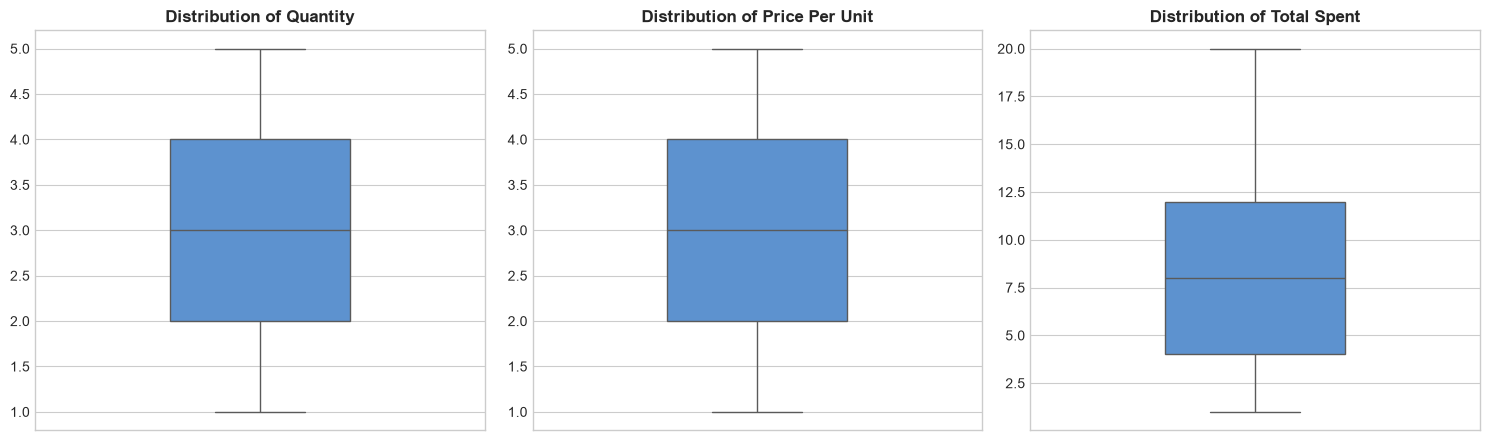

=== Distribution Summary ===
Quantity        | unique =   5 | range = [1.0, 5.0] | outliers(IQR) = 0
Price Per Unit  | unique =   6 | range = [1.0, 5.0] | outliers(IQR) = 0
Total Spent     | unique =  16 | range = [1.0, 20.0] | outliers(IQR) = 0

จำนวนแถวต่อประเภทสินค้า (Item):
Item
juice       1499
coffee      1165
cake        1139
sandwich    1131
smoothie    1096
cookie      1092
tea         1089
salad        910
unknown      337
error        283
Name: count, dtype: int64

=== Correlation with Target (Total Spent) ===
Quantity          0.6546
Price Per Unit    0.5785
Name: Total Spent, dtype: float64

สัดส่วนแถวที่ Total Spent = Quantity × Price Per Unit: 88.03%


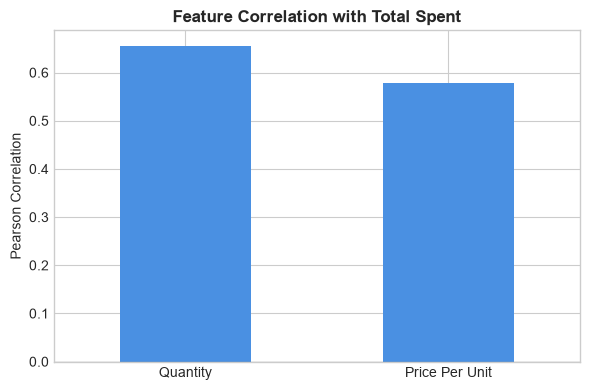


=== Bias-Variance: Polynomial Regression (Quantity → Total Spent) ===
 Degree  Train MSE  Test MSE
      1    16.1141   16.0279
      2    16.0458   15.9697
      3    16.0060   15.9302
      4    16.0010   15.9265
      5    16.0010   15.9265
      6    16.0010   15.9265
      7    16.0010   15.9265
      8    16.0010   15.9265
      9    16.0010   15.9265
     10    16.0010   15.9265
     11    16.5422   16.4022
     12    16.5939   16.4495
     13    16.6306   16.4831
     14    16.6562   16.5067
     15    16.6738   16.5229

Optimal complexity: degree = 10 (Test MSE = 15.9265)


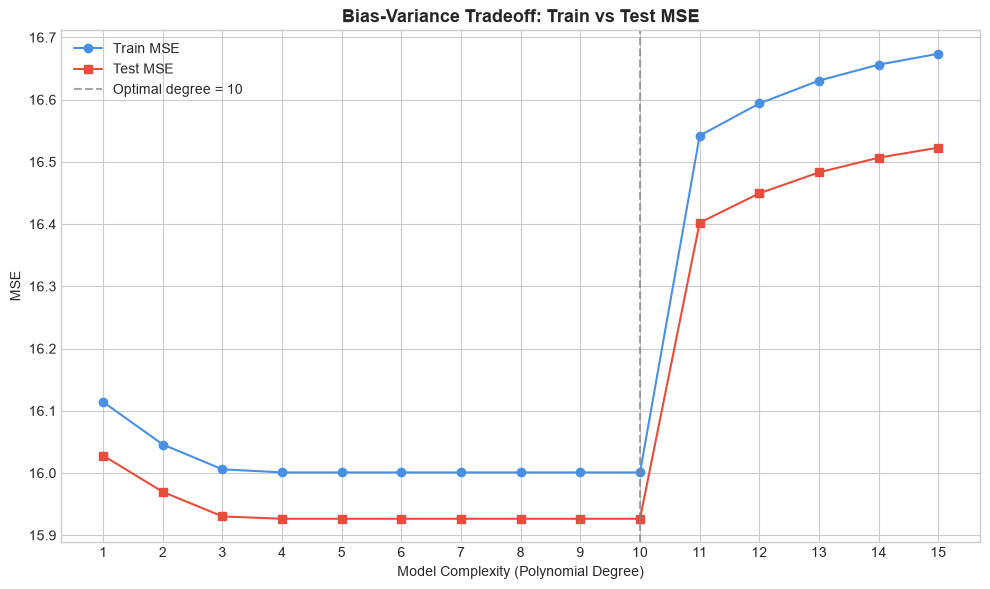

In [5]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: วิเคราะห์ distribution ของ features, correlation กับ target,
# และแสดง Bias-Variance Tradeoff ผ่าน Train/Test MSE ของ model complexity ต่างๆ

from sklearn.preprocessing import PolynomialFeatures

target = 'Total Spent'
numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']

# ── 1. Distribution ของ features สำคัญ (Boxplot) ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, y=col, ax=ax, color='#4A90E2', width=0.4)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

# สถิติประกอบ (จำนวนค่า unique + outlier ตามเกณฑ์ IQR)
print('=== Distribution Summary ===')
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f'{col:15s} | unique = {df[col].nunique():3d} | range = [{df[col].min()}, {df[col].max()}] | outliers(IQR) = {n_out}')
print('\nจำนวนแถวต่อประเภทสินค้า (Item):')
print(df['Item'].value_counts())

# ── 2. Correlation ของแต่ละ feature กับ target ────────────────────
corr_with_target = df[numeric_cols].corr()[target].drop(target).sort_values(ascending=False)
print('\n=== Correlation with Target (Total Spent) ===')
print(corr_with_target.round(4))

# ตรวจสอบความสัมพันธ์เชิงตรรกะของข้อมูล
match_pct = (df['Quantity'] * df['Price Per Unit'] == df[target]).mean() * 100
print(f'\nสัดส่วนแถวที่ Total Spent = Quantity × Price Per Unit: {match_pct:.2f}%')

plt.figure(figsize=(6, 4))
corr_with_target.plot(kind='bar', color='#4A90E2')
plt.title('Feature Correlation with Total Spent', fontsize=12, fontweight='bold')
plt.ylabel('Pearson Correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ── 3. Bias-Variance Tradeoff: Train/Test MSE ตาม model complexity ──
# หมายเหตุ: เนื่องจาก Total Spent ≈ Quantity × Price (88% ของข้อมูล) หากใช้ทั้ง 2 features
# โมเดลจะ near-deterministic (MSE ≈ 0) จึงเลือกใช้เพียง Quantity เพื่อให้เห็น tradeoff ที่แท้จริง
X = df[['Quantity']].values
y = df[target].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

degrees = list(range(1, 16))
train_mse, test_mse = [], []
for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xtr_p = poly.fit_transform(X_train)
    Xte_p = poly.transform(X_test)
    model = LinearRegression().fit(Xtr_p, y_train)
    train_mse.append(mean_squared_error(y_train, model.predict(Xtr_p)))
    test_mse.append(mean_squared_error(y_test, model.predict(Xte_p)))

results_df = pd.DataFrame({
    'Degree': degrees,
    'Train MSE': train_mse,
    'Test MSE': test_mse
})
print('\n=== Bias-Variance: Polynomial Regression (Quantity → Total Spent) ===')
print(results_df.round(4).to_string(index=False))

best_degree = int(results_df.loc[results_df['Test MSE'].idxmin(), 'Degree'])
print(f'\nOptimal complexity: degree = {best_degree} (Test MSE = {min(test_mse):.4f})')

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mse, 'o-', label='Train MSE', color='#4A90E2')
plt.plot(degrees, test_mse, 's-', label='Test MSE', color='#E74C3C')
plt.axvline(best_degree, color='gray', linestyle='--', alpha=0.7,
            label=f'Optimal degree = {best_degree}')
plt.xlabel('Model Complexity (Polynomial Degree)')
plt.ylabel('MSE')
plt.title('Bias-Variance Tradeoff: Train vs Test MSE', fontsize=13, fontweight='bold')
plt.xticks(degrees)
plt.legend()
plt.tight_layout()
plt.show()

**Insight จาก CLO2 Analysis:**

1. **Distribution ของ features:**
   - `Quantity` เป็นตัวแปร discrete จำนวน 5 ค่า (1–5, median = 3) และ `Price Per Unit` มี 6 ค่า (1, 1.5, 2, 3, 4, 5) สะท้อนราคาขายปลีกที่ร้านกำหนดเป็นเมนู ส่วน `Total Spent` มีช่วง 1–20 (median = 8)
   - ไม่มี outlier ตามเกณฑ์ IQR ในทั้ง 3 ตัวแปร เพราะข้อมูลถูก clean ช่วงค่าไว้แล้ว
   - ข้อสังเกตด้านคุณภาพข้อมูล: คอลัมน์ `Item` ยังมีหมวด `unknown` (337 แถว) และ `error` (283 แถว) รวม ~6.4% ของข้อมูล หากนำ Item ไปใช้ใน model จริงควรจัดการหมวดเหล่านี้ก่อน

2. **Feature ที่ correlate กับ target มากที่สุด:**
   - `Quantity` (r = 0.6546) มีความสัมพันธ์กับ `Total Spent` สูงที่สุด รองลงมาคือ `Price Per Unit` (r = 0.5785) — ทั้งสองเป็น feature ที่มีนัยสำคัญต่อการทำนาย target
   - ข้อมูล 88.03% ของแถวเป็นไปตามความสัมพันธ์ $Total\ Spent = Quantity \times Price\ Per\ Unit$ พอดี อีก ~12% เป็น noise ที่ค้างจากกระบวนการ clean ข้อมูล จึงมี irreducible error เล็กน้อยในการทำนาย

3. **Bias-Variance Tradeoff (Polynomial Regression: Quantity → Total Spent):**
   - **Underfitting (degree ต่ำ, 1–3):** Train/Test MSE สูงสุด (Test MSE ≈ 16.0) เพราะโมเดลเรียบง่ายเกินไป (Bias สูง) — แต่ไม่มากนักเพราะความสัมพันธ์จริงระหว่าง $E[Spent|Quantity]$ แทบเป็นเชิงเส้นอยู่แล้ว
   - **Sweet spot (degree 4–10):** Test MSE ต่ำสุดที่ ≈ 15.93 โดยค่าต่ำสุดอยู่ที่ **degree = 10** (แต่ degree 4–10 ให้ผลแทบเท่ากัน ควรเลือก degree ต่ำตามหลัก Parsimony)
   - **Overfitting (degree 11–15):** ทั้ง Train และ Test MSE พุ่งขึ้นชัดเจน (Test MSE 16.40 → 16.52) เพราะ Polynomial ดีกรีสูงบนข้อมูลที่มีเพียง 5 ค่า unique ของ Quantity ทำให้เกิดการ oscillate เพื่อไล่จับ noise (Variance สูง)
   - **รูปทรง U-curve ที่ค่อนข้างตื้น:** เพราะ (1) ข้อมูลมีขนาดใหญ่ (n = 9,741, train = 7,792 แถว) ทำให้ Variance ของ estimator ต่ำ และ (2) ความสัมพันธ์พื้นฐานเป็นเชิงเส้น ทำให้ Bias ของโมเดลเชิงเส้นต่ำอยู่แล้ว

4. **Dataset เหมาะกับ Regression หรือ Classification?**
   - **เหมาะกับ Regression** เพราะ target (`Total Spent`) เป็นตัวแปรเชิงตัวเลขที่มีการเรียงลำดับและระยะห่างระหว่างค่ามีความหมายจริง (หน่วยเงิน) — การทำนายผิดจาก 12 ไปเป็น 13 กระทบธุรกิจน้อยกว่าผิดจาก 12 ไปเป็น 20 ซึ่ง Regression จับผลกระทบเชิงขนาดนี้ได้ผ่าน MSE แต่ Classification จะถือว่าผิดเท่ากันทุกกรณี (สูญเสียข้อมูลเชิง ordinal)
   - หากจะใช้ Classification ต้องทำ binning ของ target เป็นกลุ่ม (เช่น ต่ำ/กลาง/สูง) เสียก่อน ซึ่งเป็นการตัดสินใจเชิงธุรกิจเพิ่มเติมโดยไม่จำเป็น ในขณะที่ Regression ใช้ข้อมูลได้เต็มที่และสอดคล้องกับความสัมพันธ์ $Total\ Spent \approx Quantity \times Price$ โดยตรง

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ✅ **Regression** ⬜ Classification

**เหตุผล:** target คือ `Total Spent` เป็นตัวแปรเชิงตัวเลขที่มีการเรียงลำดับและระยะห่างระหว่างค่ามีความหมายจริง (หน่วยเงิน) ตามที่วิเคราะห์ใน Part 3 (CLO2) จึงเลือกสร้าง Regression model ทั้ง 2 ตัวเพื่อทำนายยอดใช้จ่ายต่อ transaction

=== Model 1: Simple Linear Regression (Quantity → Total Spent) ===
สมการ: Total Spent = 2.5640 × Quantity + 0.8699
Train MSE = 16.1141
Test MSE = 16.0279
Test R2 = 0.4049
Test MAE = 3.2207


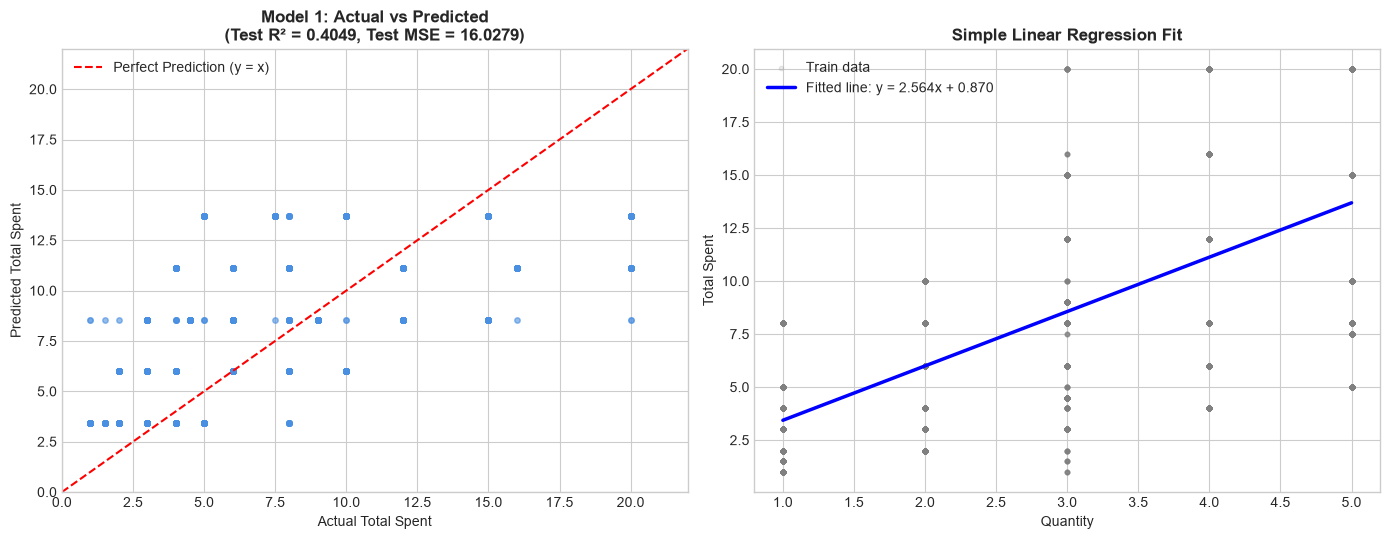

In [6]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# Model 1: Simple Linear Regression — ใช้ feature เดียวที่ correlate กับ target สูงสุด
# จาก CLO2 คือ Quantity (r = 0.6546) ในการทำนาย Total Spent

from sklearn.metrics import mean_absolute_error

target = 'Total Spent'
y = df[target].values

# Train/Test split 80/20 (random_state = 42 เดียวกับ CLO2 เพื่อความสม่ำเสมอ)
X1 = df[['Quantity']].values
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X1_train, y_train)

# Coefficients ของโมเดล
print('=== Model 1: Simple Linear Regression (Quantity → Total Spent) ===')
print(f'สมการ: Total Spent = {model1.coef_[0]:.4f} × Quantity + {model1.intercept_:.4f}')

# Metrics
pred1_train = model1.predict(X1_train)
pred1_test = model1.predict(X1_test)
metrics1 = {
    'Train MSE': mean_squared_error(y_train, pred1_train),
    'Test MSE': mean_squared_error(y_test, pred1_test),
    'Test R2': r2_score(y_test, pred1_test),
    'Test MAE': mean_absolute_error(y_test, pred1_test)
}
for k, v in metrics1.items():
    print(f'{k} = {v:.4f}')

# Visualization: Actual vs Predicted + เส้น regression บนข้อมูล
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) Actual vs Predicted (test set)
axes[0].scatter(y_test, pred1_test, alpha=0.25, s=15, color='#4A90E2')
lims = [0, 22]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction (y = x)')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual Total Spent')
axes[0].set_ylabel('Predicted Total Spent')
axes[0].set_title(f'Model 1: Actual vs Predicted\n(Test R² = {metrics1["Test R2"]:.4f}, Test MSE = {metrics1["Test MSE"]:.4f})',
                  fontsize=12, fontweight='bold')
axes[0].legend()

# (b) เส้น regression บน scatter ของข้อมูล (train set)
axes[1].scatter(X1_train, y_train, alpha=0.15, s=10, color='gray', label='Train data')
x_line = np.linspace(1, 5, 100).reshape(-1, 1)
axes[1].plot(x_line, model1.predict(x_line), 'b-', linewidth=2.5,
             label=f'Fitted line: y = {model1.coef_[0]:.3f}x + {model1.intercept_:.3f}')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Total Spent')
axes[1].set_title('Simple Linear Regression Fit', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

=== Model 2: Multiple Linear Regression (Quantity, Price Per Unit → Total Spent) ===
          Parameter   Value
      β₁ (Quantity)  2.6847
β₂ (Price Per Unit)  2.6963
     Intercept (β₀) -7.3597

สมการ: Total Spent = 2.6847 × Quantity + 2.6963 × Price Per Unit − 7.3597
Train MSE = 5.4861
Test MSE = 5.4509
Test R2 = 0.7976
Test MAE = 1.6776

[อ้างอิง] MSE ของโมเดลสมบูรณ์ Total = Quantity × Price (noise floor จาก 12% ของข้อมูลที่ขัดความสัมพันธ์) = 3.4799


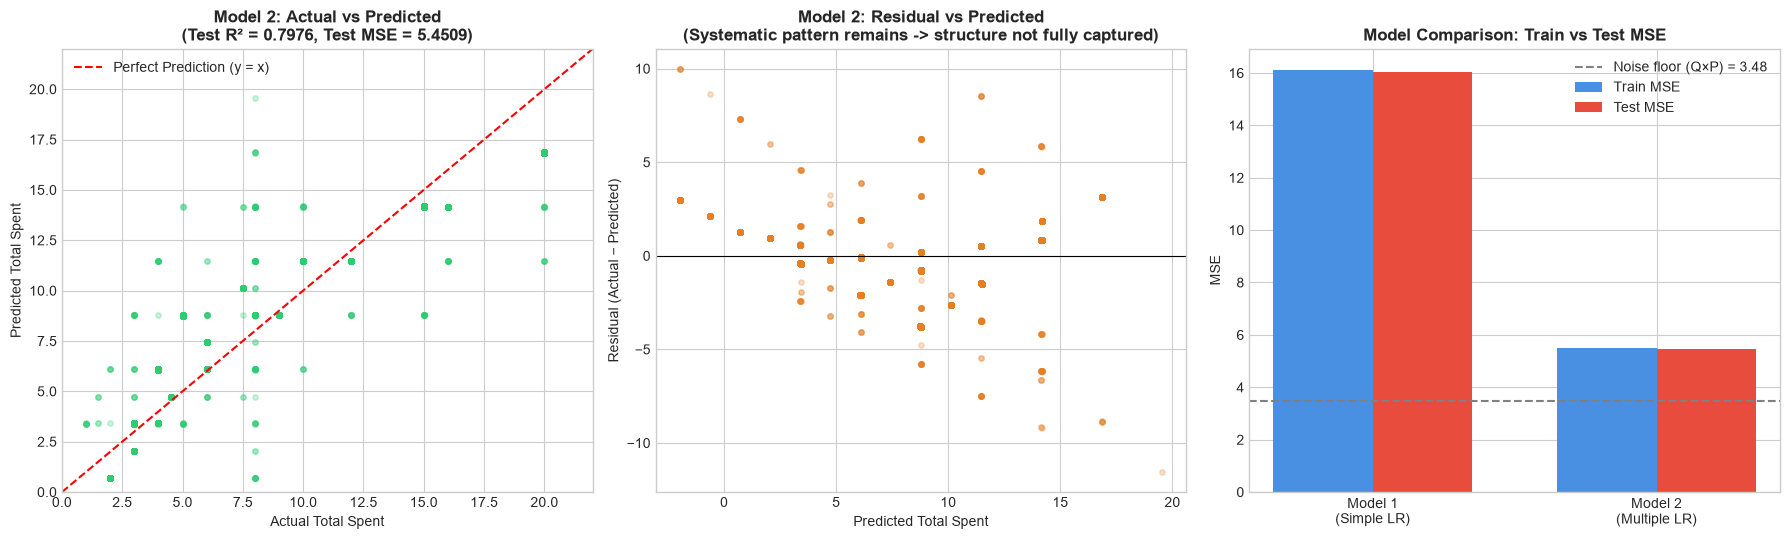

In [7]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# Model 2: Multiple Linear Regression — ใช้ทุก features (Quantity, Price Per Unit)
# ใช้ partition ชุดเดียวกับ Model 1 (random_state = 42) เพื่อให้เปรียบเทียบกันอย่างเป็นธรรม

X2 = df[['Quantity', 'Price Per Unit']].values
X2_train, X2_test, _, _ = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y_train)

# Coefficients ของโมเดล
print('=== Model 2: Multiple Linear Regression (Quantity, Price Per Unit → Total Spent) ===')
coef_df = pd.DataFrame({
    'Parameter': ['β₁ (Quantity)', 'β₂ (Price Per Unit)', 'Intercept (β₀)'],
    'Value': [model2.coef_[0], model2.coef_[1], model2.intercept_]
})
print(coef_df.round(4).to_string(index=False))
_b2 = f'+ {model2.intercept_:.4f}' if model2.intercept_ >= 0 else f'− {abs(model2.intercept_):.4f}'
print(f'\nสมการ: Total Spent = {model2.coef_[0]:.4f} × Quantity + {model2.coef_[1]:.4f} × Price Per Unit {_b2}')

# Metrics
pred2_train = model2.predict(X2_train)
pred2_test = model2.predict(X2_test)
metrics2 = {
    'Train MSE': mean_squared_error(y_train, pred2_train),
    'Test MSE': mean_squared_error(y_test, pred2_test),
    'Test R2': r2_score(y_test, pred2_test),
    'Test MAE': mean_absolute_error(y_test, pred2_test)
}
for k, v in metrics2.items():
    print(f'{k} = {v:.4f}')

# อ้างอิง noise floor: MSE ของโมเดลที่รู้ความสัมพันธ์จริง Q × P
mse_oracle = mean_squared_error(y, df['Quantity'].values * df['Price Per Unit'].values)
print(f'\n[อ้างอิง] MSE ของโมเดลสมบูรณ์ Total = Quantity × Price (noise floor จาก 12% ของข้อมูลที่ขัดความสัมพันธ์) = {mse_oracle:.4f}')

# Visualization: Actual vs Predicted + Residual + เปรียบเทียบ MSE
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) Actual vs Predicted (test set)
axes[0].scatter(y_test, pred2_test, alpha=0.25, s=15, color='#2ECC71')
lims = [0, 22]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction (y = x)')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual Total Spent')
axes[0].set_ylabel('Predicted Total Spent')
axes[0].set_title(f'Model 2: Actual vs Predicted\n(Test R² = {metrics2["Test R2"]:.4f}, Test MSE = {metrics2["Test MSE"]:.4f})',
                  fontsize=12, fontweight='bold')
axes[0].legend()

# (b) Residual vs Predicted — ตรวจดูว่า error มี pattern ซ่อนอยู่ไหม
residuals2 = y_test - pred2_test
axes[1].scatter(pred2_test, residuals2, alpha=0.25, s=15, color='#E67E22')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Predicted Total Spent')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Model 2: Residual vs Predicted\n(Systematic pattern remains -> structure not fully captured)', fontsize=12, fontweight='bold')

# (c) เปรียบเทียบ Train/Test MSE ของทั้ง 2 โมเดล
x_pos = np.arange(2)
width = 0.35
axes[2].bar(x_pos - width/2, [metrics1['Train MSE'], metrics2['Train MSE']], width,
            label='Train MSE', color='#4A90E2')
axes[2].bar(x_pos + width/2, [metrics1['Test MSE'], metrics2['Test MSE']], width,
            label='Test MSE', color='#E74C3C')
axes[2].axhline(mse_oracle, color='gray', linestyle='--', linewidth=1.5,
                label=f'Noise floor (Q×P) = {mse_oracle:.2f}')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(['Model 1\n(Simple LR)', 'Model 2\n(Multiple LR)'])
axes[2].set_ylabel('MSE')
axes[2].set_title('Model Comparison: Train vs Test MSE', fontsize=12, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

**สรุป Model Comparison:**

| Model | Train MSE | Test MSE | รายละเอียด |
|-------|-----------|----------|------------|
| Model 1: Simple Linear Regression (Quantity) | 16.1141 | 16.0279 | R² = 0.4049, MAE = 3.2207 — ใช้ 1 feature (ที่ correlate สูงสุดจาก CLO2) |
| Model 2: Multiple Linear Regression (Quantity, Price Per Unit) | **5.4861** | **5.4509** | R² = **0.7976**, MAE = **1.6776** — ใช้ทุก features |

**Insight:**
1. **Model 2 (Multiple LR) ดีกว่าชัดเจน** — การเพิ่ม `Price Per Unit` เข้าไปช่วยลด Test MSE ลง 66% (16.03 → 5.45) และเพิ่ม R² จาก 0.40 เป็น 0.80 เพราะ Model 1 มองไม่เห็นข้อมูลราคาต่อหน่วยซึ่ง correlate กับ target สูงเป็นอันดับสอง จึงทำนายได้เป็นเพียงเส้นตรงเดียวต่อทุก transaction

2. **ไม่มี overfitting ทั้งสองโมเดล** — Train MSE ≈ Test MSE ในทุกกรณี (16.11 vs 16.03 และ 5.49 vs 5.45) เพราะโมเดลมีพารามิเตอร์น้อยมากเมื่อเทียบกับข้อมูล 7,792 แถว ทำให้ Variance ต่ำ ส่วน Model 1 ที่ผลาญชัดกว่าเป็น **Underfitting (High Bias เชิงโครงสร้าง)** สอดคล้องกับ Bias-Variance ที่วิเคราะห์ใน CLO2

3. **ข้อจำกัดเชิงโครงสร้างของ Linear Model:** จาก Residual Plot ของ Model 2 จะเห็น pattern ที่ไม่ใช่การสุ่ม — เพราะความสัมพันธ์จริงของข้อมูลคือ $Total\ Spent \approx Quantity \times Price$ (multiplicative interaction) แต่ Multiple Linear Regression เรียนรู้ได้เพียง "ระนาบ" (additive: $\beta_1 Q + \beta_2 P$) เท่านั้น จึงยังสูงกว่า noise floor ที่ 3.48 อยู่ — หากต้องการลดต่อไปอีกต้องเพิ่ม interaction term ($Q \times P$) หรือใช้โมเดลที่จับ interaction ได้

4. **การตีความ Coefficients ของ Model 2:** $\beta_1 = 2.68$ (จำนวนชิ้นเพิ่ม 1 ชิ้น → ยอดใช้จ่ายเพิ่มเฉลี่ย 2.68 หน่วย) และ $\beta_2 = 2.70$ (ราคาต่อหน่วยเพิ่ม 1 หน่วย → ยอดใช้จ่ายเพิ่มเฉลี่ย 2.70 หน่วย) — สองค่าใกล้เคียงกันสะท้อนว่าโมเดลพยายาม "แชร์" น้ำหนักของผลคูณ $Q \times P$ ออกเป็นสองเทอม additive เท่าที่ทำได้

5. **การเชื่อมโยงต่อ:** Model 2 คือโมเดลที่ดีกว่าในเชิงโครงสร้าง แต่การเปรียบเทียบบน train/test split เดียวอาจมีความไม่แน่นอน ใน Part 5 (CLO4) จะยืนยันความเหนือกว่านี้อีกครั้งด้วย 5-Fold Cross-Validation

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

In [8]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

# TODO:
# models = {
#     'Model 1': ???,
#     'Model 2': ???,
#     'Model 3': ???,
# }
#
# for name, model in models.items():
#     scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
#     cv_mse = -scores.mean()
#     print(f'{name}: CV MSE = {cv_mse:.4f}')
pass

**Best Model จาก Cross-Validation:** [ระบุ]

**เหตุผล:**
> [อธิบาย: CV MSE ต่ำสุดคือเท่าไหร่? มี overfitting ไหม? เชื่อมกับ Bias-Variance อย่างไร?]

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> [สรุป findings หลักจากแต่ละ CLO ใน 4-5 bullet points]
- CLO1: ...
- CLO2: ...
- CLO3: ...
- CLO4: ...

**6.2 Limitations:**
> [อะไรที่ทำไม่ได้หรือมีข้อจำกัด เช่น dataset เล็กเกินไป, missing values, features ไม่ครบ]

**6.3 ขั้นตอนต่อไป (Future Work):**
> [ถ้ามีเวลามากกว่านี้จะทำอะไรต่อ]

**6.4 Connection กับ Topics ในวิชา:**
> [เชื่อมกับ Week ต่างๆ ที่เรียนมา ว่า concept ไหนนำมาใช้จริงในโครงงานนี้]

---
**Acknowledgements:** [ขอบคุณแหล่งข้อมูล / tools / references ที่ใช้]